# **Ejercicio 4 - Análisis exploratorio utilizando DuckDB**

En este ejercicio se realiza un análisis exploratorio de los viajes de taxis amarillos y verdes de 2026 (enero a agosto), consultando directamente los archivos Parquet con DuckDB.

## **4.1 Preguntas de análisis**

Las preguntas se plantearon a partir de las características del conjunto de datos identificadas en el Ejercicio 3. Dado que por el momento solo se cuenta con datos de 2026, el comportamiento temporal se analiza por mes; en el Ejercicio 8, al incorporar 2024 y 2025, estas mismas preguntas se extienden para analizar la evolución por año.

**Comportamiento temporal de los viajes**

- **P1:** ¿Cómo evoluciona la cantidad de viajes por mes, por tipo de taxi y en conjunto?
- **P2:** ¿En qué días de la semana y horas del día se concentra la demanda de viajes?

**Características de los viajes**

- **P3:** ¿Cuál es la distancia y duración típica de los viajes, y cómo cambian entre meses?
- **P4:** ¿Cómo evoluciona la tarifa base junto con los recargos adicionales a lo largo de los meses?

**Diferencias entre taxis amarillos y verdes**

- **P5:** ¿En qué tipo de taxi se recorre una mayor distancia por viaje?
- **P6:** ¿Cómo se comparan los montos pagados en taxis amarillos y verdes, y qué tan representativo es el monto máximo de cada uno?

**Variables relacionadas con el pago**

- **P7:** ¿Cómo se distribuyen las formas de pago en cada tipo de taxi?
- **P8:** ¿Cómo evoluciona la propina por mes y en qué mes se dan las propinas más altas? Se analizan únicamente los pagos con tarjeta, ya que las propinas en efectivo no se registran.
- **P9:** ¿Qué tan frecuentes son los cargos especiales (aeropuerto, congestión, zona de congestión de Manhattan y recargo nocturno o de hora pico) y cuánto aportan al monto total?

**Distribución de los valores relevantes**

- **P10:** ¿Cómo se distribuyen la distancia, la tarifa y la propina, y qué tan concentrados o sesgados están sus valores?

**Valores atípicos o inconsistencias**

- **P11:** ¿Qué mes generó el mayor y el menor monto total cobrado, y qué lo explica?
- **P12:** ¿Qué proporción de viajes presenta valores atípicos o inconsistentes, de los identificados en el 3.6, y cómo cambian los promedios al excluirlos?

## **Preparación de los datos: análisis de nulos y limpieza**

Antes de responder las preguntas se analizó si el bloque de registros con nulos identificado en el 3.6 tiene una explicación o si se trata de un error. Los resultados indican que no es un error: estos viajes tienen distancias, duraciones y montos totales válidos, por lo que sí ocurrieron. Su patrón es consistente con viajes de tarifa flexible (*Flex Fare*), es decir, viajes con un precio acordado previamente, en los que no se registran la cantidad de pasajeros, la tarifa aplicada ni las propinas. Por ejemplo, el proveedor 6 tiene el 100 % de sus viajes en este bloque mientras que el proveedor 7 no tiene ninguno, solo el 8 % de estos viajes registra propina contra el 78.5 % del resto, y su proporción aumenta en la madrugada, llegando a más del 50 % de los viajes a las 4:00.

In [1]:
import duckdb
import matplotlib.pyplot as plt

ANIO = 2026  # este ejercicio analiza los datos de 2026
RUTA_TODOS = f"../data/raw/*/{ANIO}/*.parquet"

con = duckdb.connect()

# Vista que unifica amarillos y verdes (misma definicion que en el Ejercicio 3)
con.sql(f"""
    CREATE OR REPLACE VIEW viajes AS
    SELECT regexp_extract(filename, '(yellow|green)_tripdata', 1)         AS tipo,
           regexp_extract(filename, '_(\\d{{4}}-\\d{{2}})\\.parquet', 1) AS mes_archivo,
           COALESCE(tpep_pickup_datetime, lpep_pickup_datetime)            AS pickup,
           COALESCE(tpep_dropoff_datetime, lpep_dropoff_datetime)          AS dropoff,
           passenger_count IS NULL AND RatecodeID IS NULL                  AS sin_metadatos,
           *
    FROM read_parquet('{RUTA_TODOS}', filename = true, union_by_name = true)
""")

# Comparacion del bloque sin metadatos contra el resto de viajes
con.sql("""
    SELECT tipo,
           sin_metadatos,
           COUNT(*)                                             AS viajes,
           ROUND(MEDIAN(trip_distance), 2)                      AS distancia_mediana,
           ROUND(MEDIAN(epoch(dropoff - pickup) / 60), 1)       AS duracion_mediana_min,
           ROUND(MEDIAN(total_amount), 2)                       AS total_mediano,
           ROUND(100 * AVG((tip_amount > 0)::INT), 1)           AS pct_con_propina
    FROM viajes
    GROUP BY tipo, sin_metadatos
    ORDER BY tipo DESC, sin_metadatos
""").df()

,tipo,sin_metadatos,viajes,distancia_mediana,duracion_mediana_min,total_mediano,pct_con_propina
0,yellow,False,21986667,1.67,12.7,21.90,78.5
1,yellow,True,7716688,2.60,17.0,29.23,8.1
2,green,False,288339,1.88,12.1,19.68,69.0
3,green,True,48775,4.89,25.6,26.44,16.1


In [2]:
# Proporcion del bloque por proveedor de tecnologia
con.sql("""
    SELECT tipo,
           VendorID,
           COUNT(*)                                   AS viajes,
           ROUND(100 * AVG(sin_metadatos::INT), 1)    AS pct_sin_metadatos
    FROM viajes
    GROUP BY tipo, VendorID
    ORDER BY tipo DESC, VendorID
""").df()

,tipo,VendorID,viajes,pct_sin_metadatos
0,yellow,1,5467071,16.4
1,yellow,2,23809774,28.4
2,yellow,6,59390,100.0
3,yellow,7,367120,0.0
4,green,1,28696,1.8
5,green,2,273571,4.9
6,green,6,34847,100.0


In [3]:
# Proporcion del bloque por hora del dia (taxis amarillos)
con.sql("""
    SELECT hour(pickup)                               AS hora,
           ROUND(100 * AVG(sin_metadatos::INT), 1)    AS pct_sin_metadatos
    FROM viajes
    WHERE tipo = 'yellow'
    GROUP BY hora
    ORDER BY hora
""").df().set_index("hora").T

hora,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pct_sin_metadatos,40.0,41.8,44.2,47.4,54.3,47.7,41.6,35.0,31.7,24.0,...,18.1,17.8,18.5,22.2,24.5,25.0,26.1,27.8,32.4,37.0


Adicionalmente, a partir de junio de 2026 la TLC incorporó la columna `request_source`, que indica el origen de la solicitud del viaje. Esta columna solo tiene valor en los viajes sin metadatos, y en los amarillos el 85 % de ellos corresponde a códigos de licencia de plataformas de viajes por aplicación (`HV0003` y `HV0005`), lo que confirma que estos viajes son solicitados por aplicación con un precio acordado previamente y explica por qué no registran pasajeros, tarifa aplicada ni propinas.

In [4]:
# Origen de la solicitud (request_source, disponible desde junio de 2026) segun el bloque
con.sql("""
    SELECT tipo,
           sin_metadatos,
           COALESCE(request_source, 'Sin dato')    AS request_source,
           COUNT(*)                                AS viajes
    FROM viajes
    WHERE mes_archivo >= '2026-06'
    GROUP BY ALL
    ORDER BY tipo DESC, sin_metadatos, viajes DESC
""").df()

,tipo,sin_metadatos,request_source,viajes
0,yellow,False,Sin dato,7799665
1,yellow,True,HV0003,2295520
2,yellow,True,A,403773
3,yellow,True,HV0005,181233
4,yellow,True,EH0004,20769
5,yellow,True,CC,1879
6,yellow,True,Sin dato,962
7,yellow,True,EH0010,272
8,green,False,Sin dato,106882
9,green,True,A,18029


Dado que estos registros sí representan viajes, se conservan para las preguntas de volumen, tiempo, distancia y monto total, y se excluyen únicamente de las preguntas que dependen de las columnas que les faltan (tarifa desglosada y propinas). Por otro lado, los siguientes registros no tienen una explicación que los justifique como viajes válidos, por lo que se eliminan del análisis mediante la vista `viajes_limpios`:

- **Fecha fuera del mes de su archivo:** incluye fechas de 2001 o 2008 dentro de archivos de 2026.
- **Duración inválida:** viajes que terminan antes o al mismo tiempo que inician, o que duran más de 24 horas.
- **Distancia inválida:** viajes con distancia de cero o mayor a 100 millas, que no corresponden a un recorrido dentro de la ciudad.
- **Montos inválidos:** tarifa negativa o total menor o igual a cero, que corresponden a reembolsos o ajustes y no a viajes.

En total se eliminan 1,476,696 registros, es decir, el 4.9 % del conjunto, y el análisis se realiza sobre 28,563,773 viajes.

In [5]:
con.sql("""
    CREATE OR REPLACE VIEW viajes_limpios AS
    SELECT *,
           epoch(dropoff - pickup) / 60 AS duracion_min
    FROM viajes
    WHERE strftime(pickup, '%Y-%m') = mes_archivo
      AND dropoff > pickup AND dropoff - pickup <= INTERVAL 24 HOUR
      AND trip_distance > 0 AND trip_distance <= 100
      AND fare_amount >= 0 AND total_amount > 0
""")

# Registros afectados por cada regla (un registro puede incumplir varias)
con.sql("""
    SELECT tipo,
           COUNT(*)                                                                         AS total,
           COUNT(*) FILTER (WHERE strftime(pickup, '%Y-%m') <> mes_archivo)                 AS fecha_fuera_del_mes,
           COUNT(*) FILTER (WHERE NOT (dropoff > pickup
                                       AND dropoff - pickup <= INTERVAL 24 HOUR))           AS duracion_invalida,
           COUNT(*) FILTER (WHERE NOT (trip_distance > 0 AND trip_distance <= 100))         AS distancia_invalida,
           COUNT(*) FILTER (WHERE NOT (fare_amount >= 0 AND total_amount > 0))              AS monto_invalido
    FROM viajes
    GROUP BY tipo
    ORDER BY tipo DESC
""").df().merge(
    con.sql("SELECT tipo, COUNT(*) AS validos FROM viajes_limpios GROUP BY tipo").df(), on="tipo"
)

,tipo,total,fecha_fuera_del_mes,duracion_invalida,distancia_invalida,monto_invalido,validos
0,yellow,29703355,146,371946,953454,167228,28240105
1,green,337114,98,238,12284,1568,323668


## **4.2, 4.3 y 4.4 Construcción de consultas, documentación y explicación de los resultados**

Para cada pregunta se presenta la respuesta y debajo la consulta ejecutada sobre la vista `viajes_limpios`, que lee directamente los archivos Parquet. Las consultas se encuentran también, de forma consolidada, en [`../sql/ejercicio_4.sql`](../sql/ejercicio_4.sql).

### **P1: ¿Cómo evoluciona la cantidad de viajes por mes, por tipo de taxi y en conjunto?**

La cantidad de viajes crece de enero a mayo, cuando alcanza su punto máximo con 3,956,314 viajes, y luego desciende hasta agosto, el mes con menos viajes (3,203,104). Los taxis verdes siguen un patrón similar, pero representan apenas entre el 1.1 % y el 1.2 % de los viajes de cada mes.

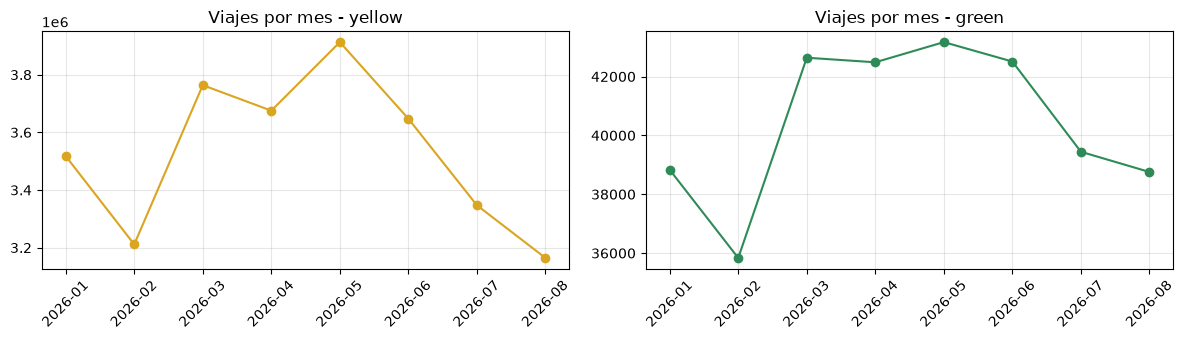

,mes,yellow,green,total,pct_green
0,2026-01,3517706,38831,3556537,1.09
1,2026-02,3211302,35836,3247138,1.10
2,2026-03,3763830,42639,3806469,1.12
3,2026-04,3675330,42484,3717814,1.14
4,2026-05,3913145,43169,3956314,1.09
5,2026-06,3647360,42509,3689869,1.15
6,2026-07,3347085,39443,3386528,1.16
7,2026-08,3164347,38757,3203104,1.21


In [6]:
p1 = con.sql("""
    SELECT strftime(pickup, '%Y-%m')                    AS mes,
           COUNT(*) FILTER (WHERE tipo = 'yellow')      AS yellow,
           COUNT(*) FILTER (WHERE tipo = 'green')       AS green,
           COUNT(*)                                     AS total,
           ROUND(100.0 * COUNT(*) FILTER (WHERE tipo = 'green') / COUNT(*), 2) AS pct_green
    FROM viajes_limpios
    GROUP BY mes
    ORDER BY mes
""").df()

fig, ejes = plt.subplots(1, 2, figsize=(12, 3.5))
for eje, tipo, color in zip(ejes, ["yellow", "green"], ["goldenrod", "seagreen"]):
    eje.plot(p1["mes"], p1[tipo], marker="o", color=color)
    eje.set_title(f"Viajes por mes - {tipo}")
    eje.tick_params(axis="x", rotation=45)
    eje.grid(alpha=0.3)
plt.tight_layout()
plt.show()
p1

### **P2: ¿En qué días de la semana y horas del día se concentra la demanda de viajes?**

Los jueves y sábados son los días con más viajes (cerca de 129 mil por día) y los lunes los de menos (97 mil), aunque los taxis verdes tienen menos viajes en fin de semana. Por hora, los amarillos alcanzan su pico entre las 17:00 y las 21:00 y mantienen actividad en la noche, mientras que los verdes tienen su pico antes, entre las 15:00 y las 18:00, y casi no tienen viajes de madrugada.

In [7]:
# Viajes promedio por dia, para no favorecer a los dias que aparecen mas veces en el periodo
con.sql("""
    SELECT isodow(pickup)                                                       AS num_dia,
           ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'][isodow(pickup)]
                                                                                AS dia,
           ROUND(COUNT(*) / COUNT(DISTINCT pickup::DATE))                       AS viajes_por_dia,
           ROUND(COUNT(*) FILTER (WHERE tipo = 'yellow') / COUNT(DISTINCT pickup::DATE)) AS yellow_por_dia,
           ROUND(COUNT(*) FILTER (WHERE tipo = 'green') / COUNT(DISTINCT pickup::DATE))  AS green_por_dia
    FROM viajes_limpios
    GROUP BY num_dia, dia
    ORDER BY num_dia
""").df()

,num_dia,dia,viajes_por_dia,yellow_por_dia,green_por_dia
0,1,Lunes,97228.0,95908.0,1319.0
1,2,Martes,114615.0,113175.0,1440.0
2,3,Miércoles,122126.0,120633.0,1493.0
3,4,Jueves,128967.0,127437.0,1530.0
4,5,Viernes,122062.0,120676.0,1386.0
5,6,Sábado,129775.0,128665.0,1111.0
6,7,Domingo,108098.0,107046.0,1052.0


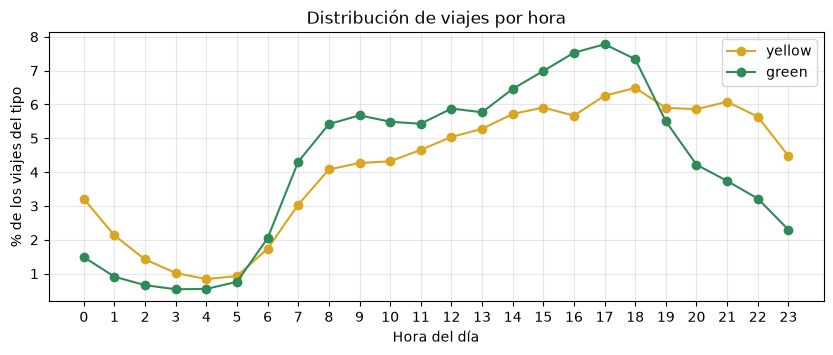

In [8]:
# Porcentaje de los viajes de cada tipo que ocurre en cada hora
p2_hora = con.sql("""
    SELECT hour(pickup) AS hora,
           ROUND(100 * COUNT(*) FILTER (WHERE tipo = 'yellow')
                 / SUM(COUNT(*) FILTER (WHERE tipo = 'yellow')) OVER (), 2) AS pct_yellow,
           ROUND(100 * COUNT(*) FILTER (WHERE tipo = 'green')
                 / SUM(COUNT(*) FILTER (WHERE tipo = 'green')) OVER (), 2)  AS pct_green
    FROM viajes_limpios
    GROUP BY hora
    ORDER BY hora
""").df()

fig, eje = plt.subplots(figsize=(10, 3.5))
eje.plot(p2_hora["hora"], p2_hora["pct_yellow"], marker="o", color="goldenrod", label="yellow")
eje.plot(p2_hora["hora"], p2_hora["pct_green"], marker="o", color="seagreen", label="green")
eje.set_xticks(range(24))
eje.set_xlabel("Hora del día")
eje.set_ylabel("% de los viajes del tipo")
eje.set_title("Distribución de viajes por hora")
eje.legend()
eje.grid(alpha=0.3)
plt.show()

### **P3: ¿Cuál es la distancia y duración típica de los viajes, y cómo cambian entre meses?**

Un viaje típico recorre cerca de 1.9 millas y dura alrededor de 14 minutos (mediana), valores que se mantienen estables entre meses, con un ligero aumento de la distancia en julio y agosto. El promedio es mayor (alrededor de 3.5 millas y 18 minutos), ya que unos pocos viajes largos lo elevan.

In [9]:
con.sql("""
    SELECT strftime(pickup, '%Y-%m')          AS mes,
           ROUND(AVG(trip_distance), 2)       AS distancia_promedio,
           ROUND(MEDIAN(trip_distance), 2)    AS distancia_mediana,
           ROUND(AVG(duracion_min), 1)        AS duracion_promedio_min,
           ROUND(MEDIAN(duracion_min), 1)     AS duracion_mediana_min
    FROM viajes_limpios
    GROUP BY mes
    ORDER BY mes
""").df()

,mes,distancia_promedio,distancia_mediana,duracion_promedio_min,duracion_mediana_min
0,2026-01,3.49,1.90,17.5,13.5
1,2026-02,3.43,1.88,18.1,14.2
2,2026-03,3.50,1.90,17.7,13.5
3,2026-04,3.52,1.90,18.4,14.2
4,2026-05,3.52,1.94,19.1,14.7
5,2026-06,3.39,1.90,17.9,14.3
6,2026-07,3.57,2.00,17.5,14.3
7,2026-08,3.71,2.09,17.5,14.3


### **P4: ¿Cómo evoluciona la tarifa base junto con los recargos adicionales a lo largo de los meses?**

En los taxis amarillos la tarifa base promedio se mantiene estable, entre 19.5 y 20.3 dólares, mientras que el recargo `extra` sube a partir de junio (de 1.50 a 1.65 dólares). En los verdes la tarifa base crece de forma sostenida, de 16.99 dólares en enero a 19.24 en agosto (13 % más). Esta consulta excluye los viajes sin metadatos, ya que su tarifa no está desglosada de la misma forma.

In [10]:
con.sql("""
    SELECT tipo,
           strftime(pickup, '%Y-%m')                 AS mes,
           ROUND(AVG(fare_amount), 2)                AS tarifa_base,
           ROUND(AVG(extra), 2)                      AS extra,
           ROUND(AVG(congestion_surcharge), 2)       AS congestion,
           ROUND(AVG(cbd_congestion_fee), 2)         AS zona_congestion,
           ROUND(AVG(total_amount), 2)               AS total
    FROM viajes_limpios
    WHERE NOT sin_metadatos
    GROUP BY tipo, mes
    ORDER BY tipo DESC, mes
""").df()

,tipo,mes,tarifa_base,extra,congestion,zona_congestion,total
0,yellow,2026-01,19.47,1.51,2.22,0.52,28.94
1,yellow,2026-02,19.64,1.50,2.23,0.53,29.17
2,yellow,2026-03,19.58,1.51,2.22,0.54,29.16
3,yellow,2026-04,19.90,1.51,2.22,0.53,29.52
4,yellow,2026-05,20.28,1.50,2.23,0.53,29.97
5,yellow,2026-06,19.80,1.60,2.33,0.56,29.96
6,yellow,2026-07,19.77,1.65,2.31,0.58,29.73
7,yellow,2026-08,19.75,1.62,2.29,0.57,29.60
8,green,2026-01,16.99,0.96,0.87,0.06,23.14
9,green,2026-02,17.26,0.97,0.83,0.05,23.47


### **P5: ¿En qué tipo de taxi se recorre una mayor distancia por viaje?**

Los taxis amarillos tienen una distancia promedio ligeramente mayor (3.52 contra 3.36 millas), pero la mediana es mayor en los verdes (2.14 contra 1.93 millas). Es decir, el viaje típico en taxi verde es más largo, mientras que los amarillos tienen más viajes muy largos (percentil 90 de 8.70 contra 7.52 millas), como los de aeropuerto.

In [11]:
con.sql("""
    SELECT tipo,
           ROUND(AVG(trip_distance), 2)                  AS distancia_promedio,
           ROUND(MEDIAN(trip_distance), 2)               AS distancia_mediana,
           ROUND(quantile_cont(trip_distance, 0.9), 2)   AS distancia_p90,
           ROUND(AVG(duracion_min), 1)                   AS duracion_promedio_min
    FROM viajes_limpios
    GROUP BY tipo
    ORDER BY tipo DESC
""").df()

,tipo,distancia_promedio,distancia_mediana,distancia_p90,duracion_promedio_min
0,yellow,3.52,1.93,8.70,17.9
1,green,3.36,2.14,7.52,21.2


### **P6: ¿Cómo se comparan los montos pagados en taxis amarillos y verdes, y qué tan representativo es el monto máximo de cada uno?**

El monto típico es mayor en los amarillos (mediana de 23.58 contra 20.52 dólares). El monto máximo es mayor en los verdes (1,678.20 contra 1,065.72 dólares), pero no es representativo, ya que corresponde a un viaje de casi 15 horas pagado en efectivo, y el 99 % de los viajes de ambos tipos cuesta menos de 105 dólares. Además, varios de los montos más altos de los amarillos son tarifas negociadas de alrededor de 900 dólares en viajes de menos de media milla, lo que apunta a errores de captura.

In [12]:
con.sql("""
    SELECT tipo,
           ROUND(AVG(total_amount), 2)                   AS promedio,
           ROUND(MEDIAN(total_amount), 2)                AS mediana,
           ROUND(quantile_cont(total_amount, 0.9), 2)    AS p90,
           ROUND(quantile_cont(total_amount, 0.99), 2)   AS p99,
           MAX(total_amount)                             AS maximo,
           COUNT(*) FILTER (WHERE total_amount > 500)    AS viajes_mayores_500
    FROM viajes_limpios
    GROUP BY tipo
    ORDER BY tipo DESC
""").df()

,tipo,promedio,mediana,p90,p99,maximo,viajes_mayores_500
0,yellow,30.24,23.58,54.73,104.99,1065.72,291
1,green,25.57,20.52,44.88,96.00,1678.20,20


In [13]:
# Viajes con los montos mas altos
con.sql("""
    SELECT tipo, pickup, dropoff, trip_distance, RatecodeID, payment_type, fare_amount, total_amount
    FROM viajes_limpios
    ORDER BY total_amount DESC
    LIMIT 6
""").df()

,tipo,pickup,dropoff,trip_distance,RatecodeID,payment_type,fare_amount,total_amount
0,green,2026-06-09 15:54:57,2026-06-10 06:49:53,48.46,1,2,1676.70,1678.20
1,yellow,2026-05-30 11:19:25,2026-05-30 11:56:21,5.29,<NA>,0,1061.72,1065.72
2,yellow,2026-06-18 18:17:19,2026-06-18 18:19:55,0.32,5,2,900.00,1004.24
3,yellow,2026-06-19 13:47:11,2026-06-19 14:30:08,11.19,5,2,985.00,989.25
4,yellow,2026-04-11 03:28:15,2026-04-11 03:30:25,0.42,5,2,980.00,981.00
5,yellow,2026-08-30 20:35:30,2026-08-30 20:56:38,15.26,5,2,950.00,965.92


### **P7: ¿Cómo se distribuyen las formas de pago en cada tipo de taxi?**

La tarjeta es la forma de pago principal en ambos tipos (65 % de los viajes). En los amarillos, el 25 % son viajes *Flex Fare* y solo el 9 % se paga en efectivo, mientras que en los verdes el efectivo tiene un peso mucho mayor (19 %), lo que sugiere un perfil de cliente distinto entre ambos servicios.

In [14]:
con.sql("""
    SELECT tipo,
           CASE payment_type
               WHEN 0 THEN 'Flex Fare'
               WHEN 1 THEN 'Tarjeta'
               WHEN 2 THEN 'Efectivo'
               WHEN 3 THEN 'Sin cargo'
               WHEN 4 THEN 'Disputa'
               WHEN 5 THEN 'Desconocido'
               WHEN 6 THEN 'Viaje anulado'
               ELSE 'Sin dato'
           END                                                              AS forma_de_pago,
           COUNT(*)                                                         AS viajes,
           ROUND(100 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY tipo), 2) AS porcentaje
    FROM viajes_limpios
    GROUP BY tipo, forma_de_pago
    ORDER BY tipo DESC, viajes DESC
""").df()

,tipo,forma_de_pago,viajes,porcentaje
0,yellow,Tarjeta,18460953,65.37
1,yellow,Flex Fare,7044125,24.94
2,yellow,Efectivo,2560516,9.07
3,yellow,Disputa,118145,0.42
4,yellow,Sin cargo,56366,0.20
5,green,Tarjeta,212457,65.64
6,green,Efectivo,62903,19.43
7,green,Sin dato,47311,14.62
8,green,Sin cargo,724,0.22
9,green,Disputa,273,0.08


### **P8: ¿Cómo evoluciona la propina por mes y en qué mes se dan las propinas más altas?**

Considerando únicamente los pagos con tarjeta, la propina promedio crece ligeramente de enero a junio, y junio es el mes con las propinas más altas en los amarillos (4.53 dólares, equivalente al 26.3 % de la tarifa); en los verdes el máximo se da en agosto (3.96 dólares). En general, los pasajeros dejan alrededor del 25 % de la tarifa como propina, y más del 90 % de los pagos con tarjeta incluye propina.

In [15]:
con.sql("""
    SELECT strftime(pickup, '%Y-%m')                                            AS mes,
           ROUND(AVG(tip_amount) FILTER (WHERE tipo = 'yellow'), 2)             AS propina_yellow,
           ROUND(AVG(tip_amount) FILTER (WHERE tipo = 'green'), 2)              AS propina_green,
           ROUND(100 * AVG(tip_amount / fare_amount) FILTER (WHERE fare_amount > 0), 2)
                                                                                AS propina_pct_tarifa,
           ROUND(100 * AVG((tip_amount > 0)::INT), 1)                           AS pct_con_propina
    FROM viajes_limpios
    WHERE payment_type = 1  -- tarjeta: las propinas en efectivo no se registran
    GROUP BY mes
    ORDER BY mes
""").df()

,mes,propina_yellow,propina_green,propina_pct_tarifa,pct_con_propina
0,2026-01,4.11,3.61,25.01,90.6
1,2026-02,4.14,3.69,24.78,90.5
2,2026-03,4.14,3.73,24.82,90.2
3,2026-04,4.19,3.83,24.97,90.0
4,2026-05,4.27,3.89,24.52,90.2
5,2026-06,4.53,3.88,26.31,94.8
6,2026-07,4.36,3.87,25.22,91.9
7,2026-08,4.30,3.96,24.98,90.8


### **P9: ¿Qué tan frecuentes son los cargos especiales y cuánto aportan al monto total?**

En los amarillos, el recargo por congestión es el más frecuente (90 % de los viajes), seguido del cargo de la zona de congestión de Manhattan (72 %), el recargo `extra` nocturno o de hora pico (44 %) y el cargo de aeropuerto (8.7 %). En los verdes, el recargo `extra` tiene una frecuencia similar (37 %), pero los cargos de congestión son mucho menos frecuentes (33 % y 8.5 %), ya que operan principalmente fuera de la zona de congestión. En conjunto, los cargos especiales representan el 11.7 % del monto cobrado en los amarillos y el 6.6 % en los verdes.

In [16]:
con.sql("""
    SELECT tipo,
           ROUND(100 * AVG((extra > 0)::INT), 1)                         AS pct_extra,
           ROUND(AVG(extra) FILTER (WHERE extra > 0), 2)                 AS monto_extra,
           ROUND(100 * AVG((congestion_surcharge > 0)::INT), 1)          AS pct_congestion,
           ROUND(AVG(congestion_surcharge) FILTER (WHERE congestion_surcharge > 0), 2) AS monto_congestion,
           ROUND(100 * AVG((cbd_congestion_fee > 0)::INT), 1)            AS pct_zona_congestion,
           ROUND(AVG(cbd_congestion_fee) FILTER (WHERE cbd_congestion_fee > 0), 2)     AS monto_zona_congestion,
           ROUND(100 * AVG((Airport_fee > 0)::INT), 1)                   AS pct_aeropuerto,
           ROUND(AVG(Airport_fee) FILTER (WHERE Airport_fee > 0), 2)     AS monto_aeropuerto,
           ROUND(100 * SUM(COALESCE(extra, 0) + COALESCE(congestion_surcharge, 0)
                           + COALESCE(cbd_congestion_fee, 0) + COALESCE(Airport_fee, 0))
                 / SUM(total_amount), 1)                                 AS pct_del_total
    FROM viajes_limpios
    GROUP BY tipo
    ORDER BY tipo DESC
""").df()

,tipo,pct_extra,monto_extra,pct_congestion,monto_congestion,pct_zona_congestion,monto_zona_congestion,pct_aeropuerto,monto_aeropuerto,pct_del_total
0,yellow,43.5,2.68,90.2,2.50,72.4,0.75,8.7,1.93,11.7
1,green,37.3,2.24,33.2,2.75,8.5,0.75,NaN,NaN,6.6


### **P10: ¿Cómo se distribuyen la distancia, la tarifa y la propina, y qué tan concentrados o sesgados están sus valores?**

Las tres variables están sesgadas a la derecha: la mitad de los viajes recorre menos de 1.93 millas, pero el 1 % supera las 19.5 millas; lo mismo ocurre con la tarifa (mediana de 13.5 y percentil 99 de 82.1 dólares) y con la propina (mediana de 3.29 y percentil 99 de 19.21 dólares). Por esto, la mediana describe mejor el viaje típico que el promedio.

In [17]:
def percentiles(columna: str, alias: str, filtro: str = "TRUE") -> str:
    return f"""
        SELECT '{alias}'                                   AS variable,
               ROUND(quantile_cont({columna}, 0.25), 2)   AS p25,
               ROUND(quantile_cont({columna}, 0.50), 2)   AS p50,
               ROUND(quantile_cont({columna}, 0.75), 2)   AS p75,
               ROUND(quantile_cont({columna}, 0.95), 2)   AS p95,
               ROUND(quantile_cont({columna}, 0.99), 2)   AS p99,
               ROUND(AVG({columna}), 2)                   AS promedio
        FROM viajes_limpios
        WHERE {filtro}
    """

con.sql(
    percentiles("trip_distance", "distancia (millas)")
    + " UNION ALL " + percentiles("fare_amount", "tarifa (dólares)", "NOT sin_metadatos")
    + " UNION ALL " + percentiles("tip_amount", "propina con tarjeta (dólares)", "payment_type = 1")
).df()

,variable,p25,p50,p75,p95,p99,promedio
0,distancia (millas),1.10,1.93,3.95,12.52,19.54,3.52
1,tarifa (dólares),9.30,13.50,22.60,65.00,82.10,19.77
2,propina con tarjeta (dólares),2.04,3.29,4.99,12.88,19.21,4.25


### **P11: ¿Qué mes generó el mayor y el menor monto total cobrado, y qué lo explica?**

Mayo generó el mayor monto total cobrado (120.66 millones de dólares) y agosto el menor (96.44 millones). La diferencia se explica por la cantidad de viajes y no por el precio, ya que el monto promedio por viaje se mantiene cerca de 30 dólares en todos los meses; por ejemplo, febrero tiene un total bajo por tener menos días, pero su monto por día es mayor que el de enero, julio y agosto.

In [18]:
con.sql("""
    SELECT strftime(pickup, '%Y-%m')                                       AS mes,
           ROUND(SUM(total_amount) / 1e6, 2)                               AS total_millones,
           COUNT(*)                                                        AS viajes,
           COUNT(DISTINCT pickup::DATE)                                    AS dias,
           ROUND(SUM(total_amount) / COUNT(DISTINCT pickup::DATE) / 1e6, 3) AS millones_por_dia,
           ROUND(AVG(total_amount), 2)                                     AS monto_promedio
    FROM viajes_limpios
    GROUP BY mes
    ORDER BY mes
""").df()

,mes,total_millones,viajes,dias,millones_por_dia,monto_promedio
0,2026-01,105.31,3556537,31,3.397,29.61
1,2026-02,98.66,3247138,28,3.524,30.38
2,2026-03,114.98,3806469,31,3.709,30.21
3,2026-04,111.70,3717814,30,3.723,30.05
4,2026-05,120.66,3956314,31,3.892,30.50
5,2026-06,112.73,3689869,30,3.758,30.55
6,2026-07,101.91,3386528,31,3.287,30.09
7,2026-08,96.44,3203104,31,3.111,30.11


### **P12: ¿Qué proporción de viajes presenta valores atípicos o inconsistentes y cómo cambian los promedios al excluirlos?**

Se excluyeron 1,476,696 registros (4.9 % del conjunto). El efecto más grande está en la distancia promedio, que baja de 5.64 a 3.52 millas, ya que unos pocos registros con distancias imposibles la inflaban; en cambio, la duración y el monto total promedio casi no cambian, lo que muestra que la limpieza afecta principalmente a las variables con valores extremos.

In [19]:
con.sql("""
    SELECT 'sin limpiar'                                  AS conjunto,
           COUNT(*)                                       AS viajes,
           ROUND(AVG(trip_distance), 2)                   AS distancia_promedio,
           ROUND(AVG(epoch(dropoff - pickup) / 60), 1)    AS duracion_promedio_min,
           ROUND(AVG(total_amount), 2)                    AS total_promedio
    FROM viajes
    UNION ALL
    SELECT 'limpio',
           COUNT(*),
           ROUND(AVG(trip_distance), 2),
           ROUND(AVG(duracion_min), 1),
           ROUND(AVG(total_amount), 2)
    FROM viajes_limpios
""").df()

,conjunto,viajes,distancia_promedio,duracion_promedio_min,total_promedio
0,sin limpiar,30040469,5.64,17.7,30.02
1,limpio,28563773,3.52,18.0,30.19


## **4.5 Hallazgos relevantes**

- **La demanda crece de enero a mayo y cae a partir de junio:** los viajes pasan de 3.56 millones en enero a 3.96 millones en mayo, su punto máximo, y luego bajan hasta 3.20 millones en agosto, es decir, 19 % menos que en mayo. Una posible explicación es que en la segunda mitad del año las personas destinan su dinero a otros gastos, como fiestas, regalos o el pago de matrículas; otra es que en julio y agosto muchos residentes salen de vacaciones y hay menos traslados al trabajo. Sin embargo, la propina no sigue este patrón, ya que alcanza su máximo en junio, por lo que quienes siguen tomando taxi no gastan menos por viaje. Con los datos disponibles no es posible confirmar ninguna de estas explicaciones, pero considero que vale la pena contrastarlas al incorporar 2024 y 2025.
- **La demanda no se concentra únicamente en el fin de semana:** a partir del miércoles se superan los 120 mil viajes por día, y el jueves (128,967) es prácticamente igual al sábado (129,775), que es el día con más viajes. En cambio, el lunes es el día con menos viajes (97 mil) y el domingo también baja (108 mil), lo que sugiere que el taxi se utiliza tanto para traslados de trabajo entre semana como para salidas de fin de semana.
- **Los viajes son cortos:** la mitad de los viajes recorre menos de 1.93 millas (alrededor de 3 km) y dura menos de 14 minutos, por lo que el taxi se utiliza principalmente para trayectos cortos dentro de la ciudad. El promedio es mayor (3.5 millas) porque unos pocos viajes largos lo elevan, y antes de la limpieza llegaba a 5.64 millas por los registros con distancias imposibles.
- **Los taxis amarillos reciben más propina, aunque la diferencia es pequeña:** en pagos con tarjeta, la propina promedio por mes va de 4.11 a 4.53 dólares en los amarillos y de 3.61 a 3.96 dólares en los verdes, es decir, alrededor de 0.50 dólares más por viaje en los amarillos. En conjunto, los pasajeros dejan cerca del 25 % de la tarifa como propina y más del 90 % de los pagos con tarjeta la incluye.
- **Una cuarta parte de los viajes amarillos no registra sus metadatos:** el 26 % de los viajes amarillos no tiene cantidad de pasajeros, tarifa aplicada ni propina registrada, pero sí son viajes reales: corresponden a viajes de tarifa flexible (*Flex Fare*) solicitados por aplicación, lo cual se confirma con la columna `request_source` que la TLC incorporó en junio de 2026. Tratarlos como errores y eliminarlos habría significado perder una cuarta parte de los viajes.
- **La tarifa de los taxis verdes aumenta mientras la de los amarillos se mantiene:** la tarifa base promedio de los verdes sube de 16.99 a 19.24 dólares entre enero y agosto (13 % más), mientras que la de los amarillos se mantiene entre 19.47 y 20.28 dólares durante todo el periodo.

In [20]:
# Evidencia del primer hallazgo: viajes por mes contra propina promedio con tarjeta
con.sql("""
    SELECT strftime(pickup, '%Y-%m')                                                     AS mes,
           COUNT(*)                                                                      AS viajes,
           ROUND(AVG(tip_amount) FILTER (WHERE payment_type = 1 AND tipo = 'yellow'), 2) AS propina_yellow,
           ROUND(AVG(tip_amount) FILTER (WHERE payment_type = 1 AND tipo = 'green'), 2)  AS propina_green
    FROM viajes_limpios
    GROUP BY mes
    ORDER BY mes
""").df()

,mes,viajes,propina_yellow,propina_green
0,2026-01,3556537,4.11,3.61
1,2026-02,3247138,4.14,3.69
2,2026-03,3806469,4.14,3.73
3,2026-04,3717814,4.19,3.83
4,2026-05,3956314,4.27,3.89
5,2026-06,3689869,4.53,3.88
6,2026-07,3386528,4.36,3.87
7,2026-08,3203104,4.30,3.96
